In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('../data/KV-traces-2026.zst', compression='zstd')
# To save as a standard CSV:
df.to_csv('../data/kv-traces-2026.csv', index=False)

In [3]:
file_path = '../data/kv-traces-2026.csv'
df = pd.read_csv("../data/kv-traces-2026.csv", nrows=200000)


In [22]:
print("First 10")
print(df.head(10))

print("\nCol name")
print(df.columns)

print("\nshape")
print(df.shape)
print("\nDatatypes")
print(df.dtypes)

First 10
          key   op  size  op_count  key_size  recency  frequency  recent_freq  \
0  1668757755  1.0    82         1        40       -1          1            0   
1  1668757755  0.0     0         1        40        1          2            1   
2  1668757805  1.0   208         1        63       -1          1            0   
3  1668757805  0.0     0         1        63        1          2            1   
4  1665498006  0.0   104         2        64       -1          1            0   
5  1666258101  0.0    81         2        23       -1          1            0   
6  1665497896  0.0   169        18        78       -1          1            0   
7  1665702915  1.0   109         1        40       -1          1            0   
8  1665702915  0.0     0         1        40        1          2            1   
9  1665497896  0.0   169        18        78        3          2            1   

   label  velocity  
0      1       1.0  
1      0       1.0  
2      1       1.0  
3      0       

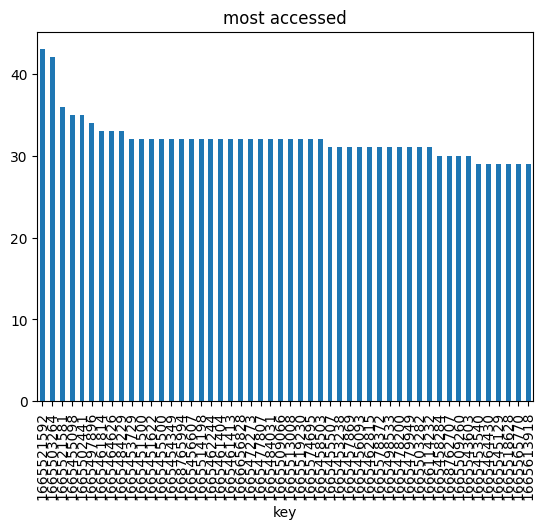

In [23]:
import matplotlib.pyplot as plt
key_col = df.columns[0] 
df[key_col].value_counts().head(50).plot(kind='bar')
plt.title("most accessed")
plt.show()

Sampling dataset

In [ ]:
df = pd.read_csv(file_path, nrows=100000)
print(df.head())
print(df.shape)

          key   op  size  op_count  key_size
0  1668757755  SET    82         1        40
1  1668757755  GET     0         1        40
2  1668757805  SET   208         1        63
3  1668757805  GET     0         1        63
4  1665498006  GET   104         2        64
(100000, 5)


Encoding and labelling

In [ ]:
import pandas as pd
from collections import deque
df = pd.read_csv(
    "../data/kv-traces-2026.csv",
    nrows=200000
)

print("Loaded dataset")

# encoding

df['op'] = df['op'].map({
    'GET': 0,
    'SET': 1
})

print("Encoded operations")

# recency

last_seen = {}
recency = []

for i, key in enumerate(df['key']):

    if key in last_seen:
        recency.append(i - last_seen[key])
    else:
        recency.append(-1)

    last_seen[key] = i

df['recency'] = recency

print("Created recency feature")

# frequency fail

freq = {}
frequency = []

for key in df['key']:

    freq[key] = freq.get(key, 0) + 1

    frequency.append(freq[key])

df['frequency'] = frequency

print("Created frequency feature")

#recent freq

window = deque(maxlen=50)

recent_freq = []

for key in df['key']:

    recent_freq.append(
        list(window).count(key)
    )

    window.append(key)

df['recent_freq'] = recent_freq

print("Created recent frequency feature")

# labels

K = 50

labels = []

keys = df['key'].tolist()

for i in range(len(keys)):

    future_window = keys[i+1:i+K+1]

    if keys[i] in future_window:
        labels.append(1)
    else:
        labels.append(0)

df['label'] = labels

print("Created labels")

#save

df.to_csv(
    "../data/processed.csv",
    index=False
)

print("\nSaved processed dataset")
print(df.head())
print(df.columns)

Loaded dataset
Encoded operations
Created recency feature
Created frequency feature
Created recent frequency feature
Created labels

Saved processed dataset
          key   op  size  op_count  key_size  recency  frequency  recent_freq  \
0  1668757755  1.0    82         1        40       -1          1            0   
1  1668757755  0.0     0         1        40        1          2            1   
2  1668757805  1.0   208         1        63       -1          1            0   
3  1668757805  0.0     0         1        63        1          2            1   
4  1665498006  0.0   104         2        64       -1          1            0   

   label  
0      1  
1      0  
2      1  
3      0  
4      1  
Index(['key', 'op', 'size', 'op_count', 'key_size', 'recency', 'frequency',
       'recent_freq', 'label'],
      dtype='str')


In [12]:
window = 50
recent_counts = []

keys = df['key'].tolist()

for i in range(len(keys)):
    start = max(0, i - window)
    count = 0
    
    for j in range(start, i):
        if keys[j] == keys[i]:
            count += 1
            
    recent_counts.append(count)

df['recent_freq'] = recent_counts

In [13]:
print(df.head())
print(df['label'].value_counts())

          key   op  size  op_count  key_size  recency  frequency  recent_freq  \
0  1668757755  1.0    82         1        40       -1          1            0   
1  1668757755  0.0     0         1        40        1          2            1   
2  1668757805  1.0   208         1        63       -1          1            0   
3  1668757805  0.0     0         1        63        1          2            1   
4  1665498006  0.0   104         2        64       -1          1            0   

   label  
0      1  
1      0  
2      1  
3      0  
4      1  
label
0    151678
1     48322
Name: count, dtype: int64


In [14]:
df.fillna(0, inplace=True)

,key,op,size,op_count,key_size,recency,frequency,recent_freq,label
0,1668757755,1.0,82,1,40,-1,1,0,1
1,1668757755,0.0,0,1,40,1,2,1,0
2,1668757805,1.0,208,1,63,-1,1,0,1
3,1668757805,0.0,0,1,63,1,2,1,0
4,1665498006,0.0,104,2,64,-1,1,0,1
...,...,...,...,...,...,...,...,...,...
199995,1665598310,0.0,158,1,79,18352,17,0,0
199996,1668883630,0.0,0,1,44,-1,1,0,0
199997,1665979383,0.0,0,1,71,-1,1,0,0
199998,1665477664,0.0,1157,2,76,98302,3,0,0


BASELINE ML MODEL FOR COMPARISON

In [24]:
import numpy as np

safe_recency = df['recency'].replace(-1, 0)
df['velocity'] = df['frequency'] / (safe_recency + 1)
df['velocity'] = df['velocity'].replace([np.inf, -np.inf], 0)

features = [
    'recency',
    'frequency',
    'op',
    'size',
    'key_size',
    'recent_freq',
    'velocity'
]

X = df[features].copy()
y = df['label']

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# X['recency'] = X['recency'].replace(-1, X['recency'].max())

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(
    imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test = pd.DataFrame(
    imputer.transform(X_test), columns=X_test.columns, index=X_test.index
)

print('Missing values', int(X_train.isna().sum().sum() + X_test.isna().sum().sum()))

Missing values 0


In [ ]:
# training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_fit_scaled, X_val_scaled, y_fit, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, shuffle=False
)

from sklearn.linear_model import SGDClassifier

# model
model = SGDClassifier(
    loss="log_loss",
    learning_rate="adaptive",
    eta0=0.001,
    penalty="l2",
    alpha=0.0001,
    warm_start=True,
    random_state=42
)
model.fit(X_fit_scaled, y_fit)

val_prob = model.predict_proba(X_val_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, val_prob)
beta = 2.0
f_scores = (1 + beta**2) * precision[:-1] * recall[:-1] / ((beta**2 * precision[:-1]) + recall[:-1] + 1e-12)
best_idx = f_scores.argmax()
threshold = thresholds[best_idx]

print('Chosen threshold:', threshold)
print('Validation PR-AUC:', average_precision_score(y_val, val_prob))

Chosen threshold: 0.14411456859059749
Validation PR-AUC: 0.75448756869931


In [17]:
# preds
y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob > threshold).astype(int)

#metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("PR-AUC:", average_precision_score(y_test, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.86445
PR-AUC: 0.773310780445686
Confusion matrix:
 [[27419  2870]
 [ 2552  7159]]
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     30289
           1       0.71      0.74      0.73      9711

    accuracy                           0.86     40000
   macro avg       0.81      0.82      0.82     40000
weighted avg       0.87      0.86      0.87     40000



In [18]:
# threshold sensitivity for the cache tradeoff
import numpy as np
threshold_grid = np.linspace(0.1, 0.9, 17)

rows = []
for candidate_threshold in threshold_grid:
    candidate_pred = (val_prob > candidate_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, candidate_pred).ravel()
    candidate_precision = tp / (tp + fp + 1e-12)
    candidate_recall = tp / (tp + fn + 1e-12)
    candidate_f1 = 2 * candidate_precision * candidate_recall / (candidate_precision + candidate_recall + 1e-12)
    beta = 2.0
    candidate_f2 = (1 + beta**2) * candidate_precision * candidate_recall / ((beta**2 * candidate_precision) + candidate_recall + 1e-12)
    rows.append({
        'threshold': candidate_threshold,
        'precision': candidate_precision,
        'recall': candidate_recall,
        'f1': candidate_f1,
        'f2': candidate_f2,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
    })

threshold_summary = pd.DataFrame(rows)
false_negative_cost = 2.0
false_positive_cost = 1.0
threshold_summary['utility'] = threshold_summary['tp'] - false_positive_cost * threshold_summary['fp'] - false_negative_cost * threshold_summary['fn']
best_utility_row = threshold_summary.loc[threshold_summary['utility'].idxmax()]

print('Top thresholds by F2 on validation:')
print(threshold_summary.sort_values(by='f2', ascending=False).head(8).round(4))
print()
print('Best threshold by cache-style utility (miss cost =', false_negative_cost, ', false alarm cost =', false_positive_cost, '):')
print(best_utility_row.round(4))

Top thresholds by F2 on validation:
   threshold  precision  recall      f1      f2    tp    fp    fn     tn  \
1       0.15     0.7154  0.7158  0.7156  0.7157  5605  2230  2225  21940   
2       0.20     0.7755  0.6903  0.7304  0.7058  5405  1565  2425  22605   
3       0.25     0.7981  0.6784  0.7334  0.6994  5312  1344  2518  22826   
4       0.30     0.8204  0.6667  0.7356  0.6926  5220  1143  2610  23027   
5       0.35     0.8319  0.6600  0.7361  0.6885  5168  1044  2662  23126   
6       0.40     0.8393  0.6568  0.7369  0.6867  5143   985  2687  23185   
7       0.45     0.8468  0.6529  0.7373  0.6842  5112   925  2718  23245   
8       0.50     0.8495  0.6510  0.7371  0.6829  5097   903  2733  23267   

   utility  
1  -1075.0  
2  -1010.0  
3  -1068.0  
4  -1143.0  
5  -1200.0  
6  -1216.0  
7  -1249.0  
8  -1272.0  

Best threshold by cache-style utility (miss cost = 2.0 , false alarm cost = 1.0 ):
threshold        0.2000
precision        0.7755
recall           0.6903
f1    

In [19]:
# probability output for further comparison
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [20]:
# feature importace

importance = pd.DataFrame({
    'feature': features,
    'weight': model.coef_[0]
})

print(importance.sort_values(by='weight', ascending=False))

       feature    weight
2           op  1.541489
5  recent_freq  0.199668
6     velocity  0.172088
1    frequency  0.041801
4     key_size  0.023406
3         size -0.072910
0      recency -0.196028


In [21]:
import joblib
import os

# os.makedirs("models", exist_ok=True)

joblib.dump(model, "../src/models/model.pkl")
joblib.dump(scaler, "../src/models/scaler.pkl")

['../src/models/scaler.pkl']